## 03. Model and Hyperparameter Tuning

In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parents[0]))
from src.validation import top_words_per_class_nb, model_check, top_words_overall_rf

In [2]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from src import tuning
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/sms_data_cleaned.csv')
df.sample(10)

,date,year,month,punctuation_count,word_count,text_count,carrier_Smart,carrier_Globe,carrier_DITO,carrier_Unknown,dedup_group_id,text_transformed,target
521,2024-02-21 13:27:06.584,2024,February,5,21,152,1,0,0,0,453,greetings gcash please advised require everyon...,1
873,2023-03-01 23:53:39.806,2023,March,7,16,105,1,0,0,0,761,real name get deposit bonus jackpot city regis...,1
664,2023-11-23 23:48:43.124,2023,November,8,30,196,1,0,0,0,583,banco de oro account restricted due unrecogniz...,1
718,2023-09-28 18:50:04.919,2023,September,8,22,158,1,0,0,0,628,taos puso kang iniimbitahan kumpanya ittbet ma...,2
709,2023-10-07 15:54:20.387,2023,October,5,24,155,1,0,0,0,620,gawin iyong unang deposito moneytoken ittbet m...,2
1020,2018-01-23 04:46:26.719,2018,January,25,78,478,1,0,0,0,898,new green township rising south maple grove fi...,2
336,2024-04-02 09:32:35.696,2024,April,4,7,63,1,0,0,0,296,magparehistro libreng moneytoken tumaya slots ...,2
770,2023-07-14 10:58:47.944,2023,July,1,4,19,1,0,0,0,673,nakuha ung pera,0
665,2023-11-21 22:35:18.930,2023,November,10,22,157,0,0,0,1,584,metamask system shown wallet yet verified veri...,0
813,2023-05-14 12:14:13.181,2023,May,5,3,26,1,0,0,0,700,content supported,0


### Tuning

In [3]:
# subset the data
X = df['text_transformed']
y = df['target']

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

train_idx, test_idx = next(sgkf.split(X, y, groups=df['dedup_group_id']))
train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

print(f"Training Data Size: {len(train_df)} | Testing Data Size: {len(test_df)}")

y_train = train_df['target']
y_test = test_df['target']

X_train = train_df['text_transformed']
X_test = test_df['text_transformed']

Training Data Size: 817 | Testing Data Size: 204


## Tuned Naive Bayes (MultinomialNB)

In [4]:
nb_grid = {
    'clf__alpha' : [0.01, 0.1, 0.5, 1.0, 2.0],
    'clf__fit_prior' : [True, False]
}

pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True)),
    ('clf', MultinomialNB())
])

nb = tuning.tune_search(X_train, y_train, train_df['dedup_group_id'], pipeline, nb_grid)
nb_pred = nb.predict(X_test)
nb_prob = nb.predict_proba(X_test)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Model Best Parameters: {'clf__alpha': 0.5, 'clf__fit_prior': False}
Best CV macro F1: 0.7145300456773762


In [5]:
tuning.show_metrics(y_test, nb_pred, nb_prob)

=== Classifier Metrics ===
ROC AUC Score: 0.89029
Accuracy Score: 0.74510

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.69      0.73        54
           1       0.76      0.78      0.77        82
           2       0.70      0.75      0.72        68

    accuracy                           0.75       204
   macro avg       0.75      0.74      0.74       204
weighted avg       0.75      0.75      0.75       204



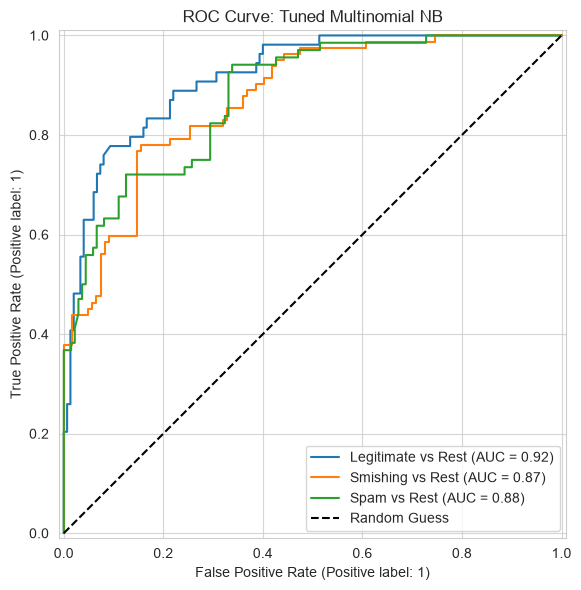

In [6]:
tuning.plot_curve(nb, X_test, y_test, 'Tuned Multinomial NB')

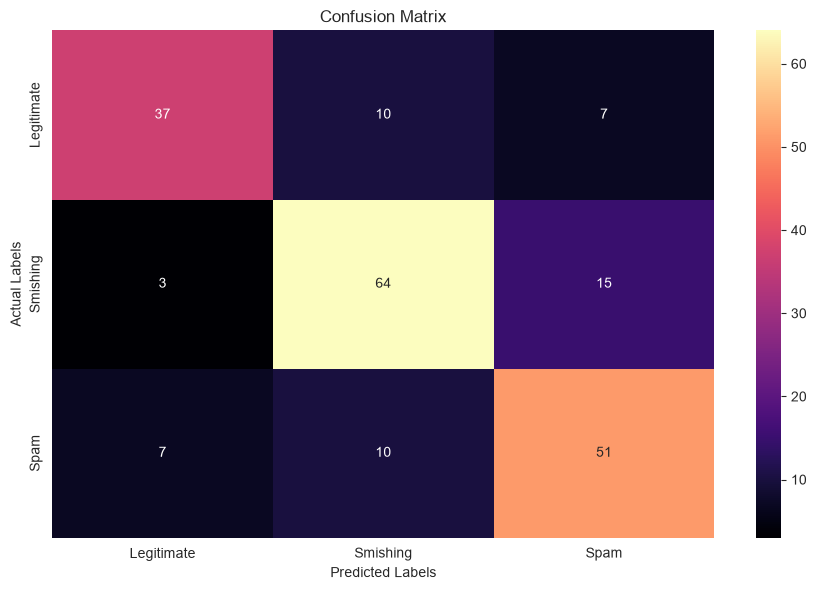

In [7]:
tuning.plot_matrix(y_test, nb_pred)

## Tuned Random Forests Clfs

In [8]:
pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True)),
    ('clf', RandomForestClassifier())
])

rf_grid = {
    'clf__n_estimators': [200, 400, 600],
    'clf__max_depth': [None, 20, 40, 60],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__class_weight': [None, 'balanced']
}

rf = tuning.tune_search(X_train, y_train, train_df['dedup_group_id'], pipeline, rf_grid)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Model Best Parameters: {'clf__class_weight': None, 'clf__max_depth': 60, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Best CV macro F1: 0.7356981236189817


In [9]:
tuning.show_metrics(y_test, rf_pred, rf_prob)

=== Classifier Metrics ===
ROC AUC Score: 0.91774
Accuracy Score: 0.77941

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.80      0.75        54
           1       0.78      0.88      0.83        82
           2       0.86      0.65      0.74        68

    accuracy                           0.78       204
   macro avg       0.78      0.77      0.77       204
weighted avg       0.79      0.78      0.78       204



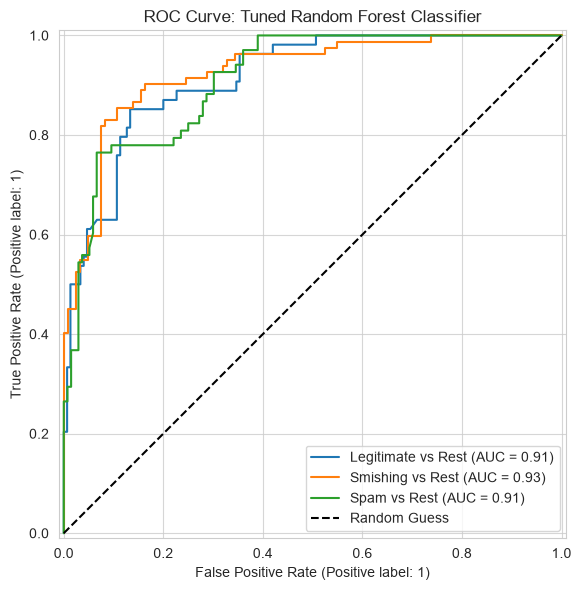

In [10]:
tuning.plot_curve(rf, X_test, y_test, 'Tuned Random Forest Classifier')

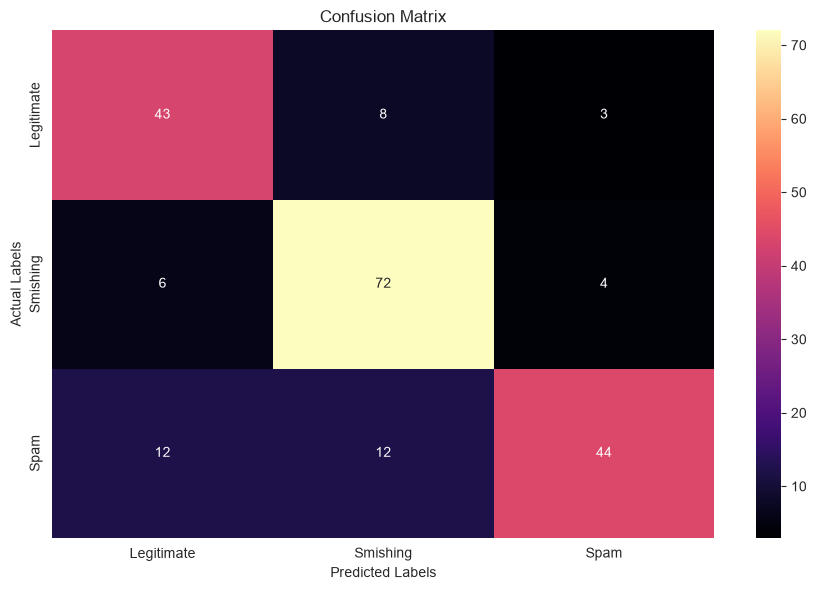

In [11]:
tuning.plot_matrix(y_test, rf_pred)

## Model Test (NB and RFS)

In [12]:
target_names = ['Legitimate', 'Smishing', 'Spam']

### Hyperparameter Tuned Naive Bayes (MultinomialNB)

In [13]:
model_check(nb, test_df, 'Tuned MultinomialNB', 20)

Predicted vs Actuals: (Tuned MultinomialNB)
[Matched] Predicted: Legitimate | Actual: Legitimate | moneytoken credit natanggap number valid lamang within hrs m
[Matched] Predicted: Smishing   | Actual: Smishing   | ygtt nakatanggap iyong number moneytoken mag register gamit 
[Matched] Predicted: Legitimate | Actual: Legitimate | make money watching youtube earn moneytoken per day contact 
[Matched] Predicted: Smishing   | Actual: Smishing   | epicwin sumali tangkilikin limitadong bonus trusted website 
[Matched] Predicted: Legitimate | Actual: Legitimate | magparehistro libreng moneytoken tumaya luckya auction lszlh
[Matched] Predicted: Smishing   | Actual: Smishing   | website bug deposit get bonus withdraw immediately expire to
[Matched] Predicted: Legitimate | Actual: Legitimate | newbies register moneytoken receive red envelopes every day 
[Matched] Predicted: Smishing   | Actual: Smishing   | sign bonus moneytoken receive game urltoken
[Matched] Predicted: Spam       | Actual: Spa

In [14]:
top_words_per_class_nb(nb, target_names, 5)

--- Top 5 words for Legitimate (NB log-odds) ---
content                    log-odds=2.978
content supported          log-odds=2.978
supported                  log-odds=2.978
tutor                      log-odds=1.894
youtube                    log-odds=1.894

--- Top 5 words for Smishing (NB log-odds) ---
points expire              log-odds=2.105
expire today               log-odds=2.023
today please               log-odds=2.023
reminds                    log-odds=2.023
reminds reward             log-odds=2.023

--- Top 5 words for Spam (NB log-odds) ---
ittbet                     log-odds=2.386
slot                       log-odds=2.101
moneytoken ittbet          log-odds=2.056
sugarplay                  log-odds=2.055
winningplus                log-odds=2.037



### Hyperparameter Tuned Random Forests

In [15]:
model_check(rf, test_df, 'Tuned Random Forests', 20)

Predicted vs Actuals: (Tuned Random Forests)
[Matched] Predicted: Legitimate | Actual: Legitimate | moneytoken credit natanggap number valid lamang within hrs m
[Matched] Predicted: Smishing   | Actual: Smishing   | ygtt nakatanggap iyong number moneytoken mag register gamit 
[Matched] Predicted: Legitimate | Actual: Legitimate | make money watching youtube earn moneytoken per day contact 
[Matched] Predicted: Smishing   | Actual: Smishing   | epicwin sumali tangkilikin limitadong bonus trusted website 
[Matched] Predicted: Legitimate | Actual: Legitimate | magparehistro libreng moneytoken tumaya luckya auction lszlh
[Matched] Predicted: Smishing   | Actual: Smishing   | website bug deposit get bonus withdraw immediately expire to
[Matched] Predicted: Legitimate | Actual: Legitimate | newbies register moneytoken receive red envelopes every day 
[Matched] Predicted: Smishing   | Actual: Smishing   | sign bonus moneytoken receive game urltoken
[Matched] Predicted: Spam       | Actual: Sp

In [16]:
top_words_overall_rf(rf, 10)

--- Top 10 words overall (RF feature importance) ---
bonus                      importance=0.0457
urltoken                   importance=0.0133
win                        importance=0.0130
moneytoken                 importance=0.0099
app                        importance=0.0095
ittbet                     importance=0.0090
join                       importance=0.0089
account                    importance=0.0086
real                       importance=0.0085
slot                       importance=0.0083
